In [2]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image


import torch
from PIL import Image
import os

import torch
from PIL import Image
import os
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Initialize function, pass in the path of the dataset and the transform object for data preprocessing.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.images = [] # A list to store the paths of all images in the dataset
        self.labels = [] # A list to store the labels of all images in the dataset
        # Only read .jpg format image files
        self.image_filenames = [f for f in os.listdir(root_dir) if f.lower().endswith('.jpg') and not f.lower().startswith('.')]
        # Enumerate the files in each folder and label the images for each category
        for i, class_name in enumerate(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith('.jpg'):
                        img_path = os.path.join(class_dir, img_name)
                        self.images.append(img_path)
                        self.labels.append(i)          
    def __len__(self):
        """
        Return the length of the dataset.
        """
        return len(self.images)
    def __getitem__(self, idx):
        """
        Get one data item according to the index.
        """
        img_path = self.images[idx] # Get the path of the image
        label = self.labels[idx] # Get the label of the image
        img = Image.open(img_path).convert("RGB") # Open the image and convert it to RGB format
        # If a transform object is passed in, use it to preprocess the image
        if self.transform is not None:
            img = self.transform(img)
        return img, label # Return the preprocessed image and its label

In [3]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
# Define the transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
# load dataset
real_train_dataset = CustomDataset('data/real_train', transform=transform)
print(len(real_train_dataset))
real_test_dataset = CustomDataset('data/real_test', transform=transform)
sketch_train_dataset = CustomDataset('data/sketch_train', transform=transform)
print(len(sketch_train_dataset))
sketch_test_dataset = CustomDataset('data/sketch_test', transform=transform)
# defines four DataLoader objects for loading training and testing sets of real pictures and sketch pictures
# Shuffle the training dataset
real_train_loader = DataLoader(real_train_dataset, batch_size=32, shuffle=True)#
real_test_loader = DataLoader(real_test_dataset, batch_size=32, shuffle=False)
sketch_train_loader = DataLoader(sketch_train_dataset, batch_size=32, shuffle=True)#
sketch_test_loader = DataLoader(sketch_test_dataset, batch_size=32, shuffle=False)

3984
1956


In [4]:
#加载模型
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train(src_loader, tar_loader, model, optimizer, criterion):
    #tar_loader is useless
    # Set model as train state
    model.train()
    # Initialize counters for accuracy and loss
    correct = 0
    total = 0
    total_loss = 0
    for src_batch, tar_batch in zip(src_loader, tar_loader):
        # Extract source and target images and labels
        src_images, src_labels = src_batch
        tar_images, _ = tar_batch
        # Move images and labels to the device (CPU or GPU)
        src_images, src_labels = src_images.to(device), src_labels.to(device)
        tar_images = tar_images.to(device)
        # Zero out gradients in the optimizer
        optimizer.zero_grad()
        # get the prediction result
        src_outputs = model(src_images)
        tar_outputs = model(tar_images)
        # Calculate loss on source data
        loss = criterion(src_outputs, src_labels)
        #update
        loss.backward()
        optimizer.step()
        # Accumulate loss over all batches
        total_loss += loss.item()
        # Calculate accuracy
        _, predicted = src_outputs.max(1)
        total += src_labels.size(0)
        correct += predicted.eq(src_labels).sum().item()
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(src_loader)
    return avg_loss, accuracy

def test(loader, model, criterion):
    # Set model as evaluation state
    model.eval()
    #init for calculate the accuracy
    correct = 0
    total = 0
    loss_sum = 0
    # Turn off gradient calculation because we're only testing the model
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            #get prediction from test image
            outputs = model(images)
            #caculate loss and acc
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100. * correct / total
    avg_loss = loss_sum / total
    return avg_loss, accuracy

In [6]:
#2.b
# Load the pre-trained model and fine-tune: use the ResNet-34 model as the pre-trained model, which is trained on the ImageNet dataset and can extract high-level features of images.
# Then replace the last fully connected layer (fc) of the model with a new fully connected layer with an output size of num_classes for classification.
num_classes = 10
model = models.resnet34(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
# Move model to device
model = model.to(device)
# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
print("start sketch test on sketch train")
sketch_train_losses = []
sketch_train_accs = []
sketch_test_losses = []
sketch_test_accs = []
# Train on Sketch domain
with open("log_file_2b.txt", "a") as log_file:
    for epoch in range(10):
        #train model
        sketch_train_loss, sketch_train_accuracy = train(sketch_train_loader, sketch_train_loader, model, optimizer, criterion)
        # get a accuracy of new model
        sketch_test_loss, sketch_test_accuracy = test(sketch_test_loader, model, criterion)
        sketch_train_losses.append(sketch_train_loss)
        sketch_train_accs.append(sketch_train_accuracy/100)
        sketch_test_losses.append(sketch_test_loss)
        #add accuracy to list, used for plot a accuracy graph
        sketch_test_accs.append(sketch_test_accuracy/100)
        print(f'Epoch {epoch+1} - Sketch Test Accuracy on ketch train: {sketch_test_accuracy:.2f}%.')
        log_file.write(f'Epoch {epoch+1} - Sketch Test Accuracy on sketch train: {sketch_test_accuracy:.2f}%.\n')


D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


start sketch test on sketch train
Epoch 1 - Sketch Test Accuracy on ketch train: 86.21%.
Epoch 2 - Sketch Test Accuracy on ketch train: 87.63%.
Epoch 3 - Sketch Test Accuracy on ketch train: 89.89%.
Epoch 4 - Sketch Test Accuracy on ketch train: 89.77%.
Epoch 5 - Sketch Test Accuracy on ketch train: 89.30%.
Epoch 6 - Sketch Test Accuracy on ketch train: 88.59%.
Epoch 7 - Sketch Test Accuracy on ketch train: 88.59%.
Epoch 8 - Sketch Test Accuracy on ketch train: 87.75%.
Epoch 9 - Sketch Test Accuracy on ketch train: 87.99%.
Epoch 10 - Sketch Test Accuracy on ketch train: 85.73%.


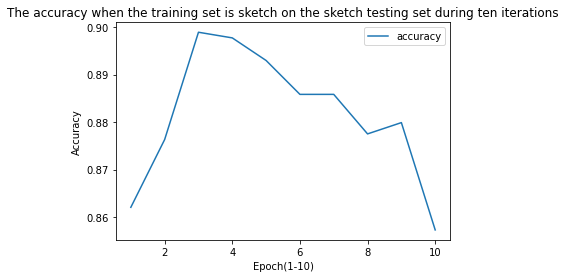

In [7]:
#2.b plot
plt.plot(np.arange(1, 11), sketch_test_accs, label='accuracy')
plt.legend()
plt.title('The accuracy when the training set is sketch on the sketch testing set during ten iterations')
plt.xlabel('Epoch(1-10)')
plt.ylabel('Accuracy')
plt.show()

In [14]:
#2.c
# Train on real domain
print("start sketch test on real train")
num_classes = 10
model = models.resnet34(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
# Move model to device
model = model.to(device)
# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
real_train_losses = []
real_train_accs = []
sketch_test_losses = []
sketch_test_accs_2 = []
with open("log_file_2c.txt", "a") as log_file:
    for epoch in range(10):
        real_train_loss, real_train_accuracy = train(real_train_loader, real_train_loader, model, optimizer, criterion)
        sketch_test_loss,sketch_test_accuracy = test(sketch_test_loader, model, criterion)
        real_train_losses.append(real_train_loss)
        real_train_accs.append(real_train_accuracy/100)
        sketch_test_losses.append(sketch_test_loss)
        sketch_test_accs_2.append(sketch_test_accuracy/100)
        print(f'Epoch {epoch+1} - Sketch Test Accuracy on real: {sketch_test_accuracy:.2f}%.')
        log_file.write(f'Epoch {epoch+1} - Sketch Test Accuracy on real: {sketch_test_accuracy:.2f}%.\n')
        
print("sketch test on real train achieve!")

start sketch test on real train


D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 - Sketch Test Accuracy on real: 51.96%.
Epoch 2 - Sketch Test Accuracy on real: 48.63%.
Epoch 3 - Sketch Test Accuracy on real: 38.76%.
Epoch 4 - Sketch Test Accuracy on real: 56.12%.
Epoch 5 - Sketch Test Accuracy on real: 48.87%.
Epoch 6 - Sketch Test Accuracy on real: 49.35%.
Epoch 7 - Sketch Test Accuracy on real: 55.17%.
Epoch 8 - Sketch Test Accuracy on real: 51.61%.
Epoch 9 - Sketch Test Accuracy on real: 43.76%.
Epoch 10 - Sketch Test Accuracy on real: 53.86%.
sketch test on real train achieve!


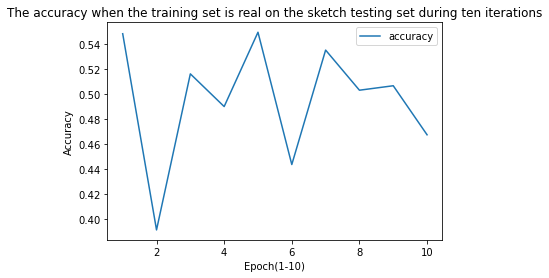

In [9]:
#2.c plot
plt.plot(np.arange(1, 11), sketch_test_accs_2, label='accuracy')
plt.legend()
plt.title('The accuracy when the training set is real on the sketch testing set during ten iterations')
plt.xlabel('Epoch(1-10)')
plt.ylabel('Accuracy')
plt.show()

In [10]:
#transfer learning from real to sketch
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
# Define domain adaptation loss function
def mmd_loss(x_src, x_tar):
    # move tensors to CPU device
    x_src = x_src.detach().cpu().numpy()
    x_tar = x_tar.detach().cpu().numpy()
    #(32, 512)
    #m and n is batch size of scr and tar 32
    m = x_src.shape[0]
    n = x_tar.shape[0]
    #the features num of m and n 512
    d = x_src.shape[1]
    # calculate kernel matrices
    K_ss = rbf_kernel(x_src, x_src)
    K_tt = rbf_kernel(x_tar, x_tar)
    K_st = rbf_kernel(x_src, x_tar)
    # calculate MMD^2
    mmd2 = (1 / (m * (m - 1))) * np.sum(K_ss - np.diag(np.diag(K_ss)))
    mmd2 += (1 / (n * (n - 1))) * np.sum(K_tt - np.diag(np.diag(K_tt)))
    mmd2 -= (2 / (m * n)) * np.sum(K_st)
    return mmd2
#code from Haoyu Song
def get_feature(model, inputs):
    # Use convolutional layer 1 for feature extraction
    features = model.conv1(inputs)
    # Batch normalization
    features = model.bn1(features)
    # Apply ReLU activation function
    features = model.relu(features)
    # Max pooling layer
    features = model.maxpool(features)
    # Use residual block layer 1 for feature extraction
    features = model.layer1(features)
    # Use residual block layer 2 for feature extraction
    features = model.layer2(features)
    # Use residual block layer 3 for feature extraction
    features = model.layer3(features)
    # Use residual block layer 4 for feature extraction
    features = model.layer4(features)
    # Average pooling layer
    features = model.avgpool(features)
    # Flatten features into a 1D tensor
    features = torch.flatten(features, 1)
    # Return the feature vector
    return features

# Define training function
def train_transfer(src_loader, tar_loader, model, optimizer, criterion, lambd):
    # Initialize variables for tracking loss and accuracy
    running_loss = 0.0
    correct = 0
    total = 0
    mmd_l = 0
    src_l = 0
    #set the model to train state
    model.train()
    # Iterate through batches of source and target data
    for src_batch, tar_batch in zip(src_loader, tar_loader):
        # Extract source images and labels, and target images
        src_images, src_labels = src_batch
        tar_images, _ = tar_batch
        # Move data to GPU
        src_images, src_labels = src_images.to(device), src_labels.to(device)
        tar_images = tar_images.to(device)
        # Zero the gradients for the optimizer
        optimizer.zero_grad()
        #get features from source image
        src_features = get_feature(model,src_images)
        #get features from target image
        tar_features = get_feature(model,tar_images)
        #get prediction from source
        src_outputs = model(src_images)
        # Calculate the loss function on the source domain data
        src_loss = criterion(src_outputs, src_labels)
        #Calculate mmd loss
        m_loss = lambd * mmd_loss(src_features, tar_features)
        # get total loss
        loss = src_loss + m_loss
        # Backpropagate the total loss to calculate gradients
        loss.backward()
        # Update model parameters using the optimizer
        optimizer.step()
        #get running loss and accuracy statistics
        running_loss += loss.item()
        mmd_l = mmd_l+m_loss
        src_l = src_l+src_loss.item()
        _, predicted = torch.max(src_outputs.data, 1)
        total += src_labels.size(0)
        correct += (predicted == src_labels).sum().item()
    train_accuracy = 100 * correct / total
    return train_accuracy,running_loss, mmd_l, src_l

In [11]:
#get model
num_classes = 10
model = models.resnet34(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
# Move model to device
model = model.to(device)
# Define Adam optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
sketch_test_acc_3 = []
total_losses = []
mmd_losses = []
src_losses = []
with open("log_file_3.txt", "a") as log_file:
    for epoch in range(20):
        real_train_accuracy,total_loss, mmd_l, src_l = train_transfer(real_train_loader, sketch_train_loader, model, optimizer, criterion, 0.01)
        _,sketch_test_accuracy = test(sketch_test_loader, model, criterion)
        sketch_test_acc_3.append(sketch_test_accuracy/100)
        total_losses.append(total_loss)
        mmd_losses.append(mmd_l)
        src_losses.append(src_l)
        print(f'Transfer learning: Epoch {epoch+1} - Sketch Test Accuracy on real: {sketch_test_accuracy:.2f}%')
        log_file.write(f'Transfer learning: Epoch {epoch+1} - Sketch Test Accuracy on real: {sketch_test_accuracy:.2f}%.\n')

D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\360Downloads\anaconda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Transfer learning: Epoch 1 - Sketch Test Accuracy on real: 54.10%
Transfer learning: Epoch 2 - Sketch Test Accuracy on real: 60.76%
Transfer learning: Epoch 3 - Sketch Test Accuracy on real: 54.46%
Transfer learning: Epoch 4 - Sketch Test Accuracy on real: 59.57%
Transfer learning: Epoch 5 - Sketch Test Accuracy on real: 57.91%
Transfer learning: Epoch 6 - Sketch Test Accuracy on real: 59.81%
Transfer learning: Epoch 7 - Sketch Test Accuracy on real: 52.56%
Transfer learning: Epoch 8 - Sketch Test Accuracy on real: 61.12%
Transfer learning: Epoch 9 - Sketch Test Accuracy on real: 54.70%
Transfer learning: Epoch 10 - Sketch Test Accuracy on real: 59.10%
Transfer learning: Epoch 11 - Sketch Test Accuracy on real: 65.04%
Transfer learning: Epoch 12 - Sketch Test Accuracy on real: 61.00%
Transfer learning: Epoch 13 - Sketch Test Accuracy on real: 60.17%
Transfer learning: Epoch 14 - Sketch Test Accuracy on real: 55.65%
Transfer learning: Epoch 15 - Sketch Test Accuracy on real: 57.43%
Tran

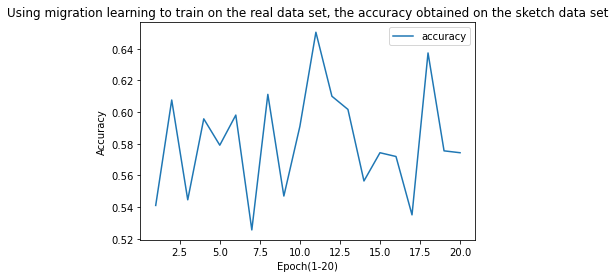

In [12]:
plt.plot(np.arange(1, 21), sketch_test_acc_3, label='accuracy')
plt.legend()
plt.title('Using migration learning to train on the real data set, the accuracy obtained on the sketch data set')
plt.xlabel('Epoch(1-20)')
plt.ylabel('Accuracy')
plt.show()

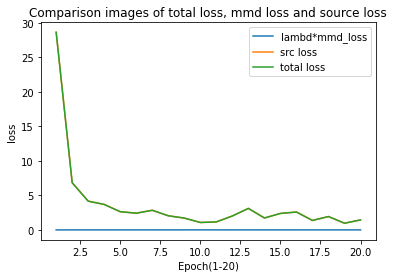

In [13]:
plt.plot(np.arange(1, 21), mmd_losses, label='lambd*mmd_loss')
plt.plot(np.arange(1, 21), src_losses, label='src loss')
plt.plot(np.arange(1, 21), total_losses, label='total loss')
plt.legend()
plt.title('Comparison images of total loss, mmd loss and source loss')
plt.xlabel('Epoch(1-20)')
plt.ylabel('loss')
plt.show()